In [71]:
import pandas as pd

url = "https://query.data.world/s/evaqrt2zzlif7stoa53otaysb6ybwk"
youtube_df = pd.read_csv(url)

In [72]:
# Show the first 5 rows of Youtube dataset

youtube_df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
2,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
3,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...
4,il_pSa5l98w,17.14.11,"MCA (Middle Class Abbayi) TEASER - Nani,Sai Pa...",Dil Raju,24,2017-11-10T04:29:50.000Z,"Nenu Local|""Nenu Local Telugu Movie""|""Nani""|""S...",6106669,98612,4185,4763,https://i.ytimg.com/vi/il_pSa5l98w/default.jpg,False,False,False,Watch MCA- Middle Class Abbayi First Look Teas...


In [73]:
#. Checking the data type of various columns that are present and we need to check whether the data is loaded properly

print(youtube_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37351 entries, 0 to 37350
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37351 non-null  object
 1   trending_date           37351 non-null  object
 2   title                   37351 non-null  object
 3   channel_title           37351 non-null  object
 4   category_id             37351 non-null  int64 
 5   publish_time            37351 non-null  object
 6   tags                    37351 non-null  object
 7   views                   37351 non-null  int64 
 8   likes                   37351 non-null  int64 
 9   dislikes                37351 non-null  int64 
 10  comment_count           37351 non-null  int64 
 11  thumbnail_link          37351 non-null  object
 12  comments_disabled       37351 non-null  bool  
 13  ratings_disabled        37351 non-null  bool  
 14  video_error_or_removed  37351 non-null  bool  
 15  de

In [74]:
# What is the correct datetime format of the 'trending_date' column?
# First, inspect one sample value to identify the date format,
# then convert the entire column to pandas datetime.

from datetime import datetime
import pandas as pd

# Inspect one sample value from the column
sample = str(youtube_df.loc[0, 'trending_date'])

# Test possible date formats
formats = [
    "%y.%m.%d",
    "%y.%d.%m",
    "%d.%m.%y",
    "%d.%y.%m",
    "%m.%d.%y",
    "%m.%y.%d"
]

for date_format in formats:
    try:
        datetime.strptime(sample, date_format)
        print("Likely format:", date_format)
        break
    except ValueError:
        continue

# Convert the entire column to pandas datetime
youtube_df['trending_date'] = pd.to_datetime(
    youtube_df['trending_date'],
    format='%y.%d.%m',
    errors='coerce'
)

# Display the converted column
youtube_df['trending_date']

Likely format: %y.%d.%m


,trending_date
0,2017-11-14
1,2017-11-14
2,2017-11-14
3,2017-11-14
4,2017-11-14
...,...
37346,2018-06-14
37347,2018-06-14
37348,2018-06-14
37349,2018-06-14


In [75]:
# Convert 'publish_time' to pandas datetime.
# Invalid values are converted to NaT (Not a Time).
youtube_df['publish_time'] = pd.to_datetime(
    youtube_df['publish_time'],
    errors='coerce'
)

# Extract the date and time components separately.
# - publish_date: date only
# - publish_timeline: time only
youtube_df['publish_date'] = youtube_df['publish_time'].dt.normalize()
youtube_df['publish_timeline'] = youtube_df['publish_time'].dt.time

# Display dataframe information:
# column names, non-null counts, and data types
youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37351 entries, 0 to 37350
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                37351 non-null  object             
 1   trending_date           37351 non-null  datetime64[ns]     
 2   title                   37351 non-null  object             
 3   channel_title           37351 non-null  object             
 4   category_id             37351 non-null  int64              
 5   publish_time            37351 non-null  datetime64[ns, UTC]
 6   tags                    37351 non-null  object             
 7   views                   37351 non-null  int64              
 8   likes                   37351 non-null  int64              
 9   dislikes                37351 non-null  int64              
 10  comment_count           37351 non-null  int64              
 11  thumbnail_link          37351 non-null  o

In [76]:
# Find all exact duplicate rows
youtube_df_dup_rows = youtube_df.loc[youtube_df.duplicated()]

# Display duplicate rows
youtube_df_dup_rows

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
1688,YAzs-timxnI,2017-11-22,Swag Se Swagat Song | Official Teaser | Salman...,YRF,10,2017-11-20 08:40:48+00:00,"Salman Khan|""Katrina Kaif""|""Tiger Zinda Hai So...",2790320,46228,5088,3807,https://i.ytimg.com/vi/YAzs-timxnI/default.jpg,False,False,False,► Subscribe Now: https://goo.gl/xs3mrY 🔔 Stay ...,2017-11-20 00:00:00+00:00,08:40:48
1689,ZJDMWVZta3M,2017-11-22,Incredibles 2 Official Teaser Trailer,Disney•Pixar,1,2017-11-18 15:43:11+00:00,"Pixar|""Disney""|""Disney Pixar""|""Pixar Movie""|""A...",17613871,369519,7892,45240,https://i.ytimg.com/vi/ZJDMWVZta3M/default.jpg,False,False,False,The teaser trailer for Incredibles 2 is here.\...,2017-11-18 00:00:00+00:00,15:43:11
1690,RVpnz8mbVDI,2017-11-22,Jaisi Karni Waisi Bharni - | Lalit Shokeen Fil...,LShokeen Films,24,2017-11-20 14:27:43+00:00,"lalit shokeen|""lalit shokeen films""|""lalit sho...",733685,31866,883,2392,https://i.ytimg.com/vi/RVpnz8mbVDI/default.jpg,False,False,False,Jaisi karni waisi bharni - jyada oversmart ban...,2017-11-20 00:00:00+00:00,14:27:43
1691,CfZSYm-mFgI,2017-11-22,Bomma Adhirindhi Song Trailer | Jawaan Telugu ...,Arunachal Creations,22,2017-11-19 17:15:38+00:00,"Bomma Adhirindhi Song Trailer|""Jawaan Telugu M...",550261,3184,426,187,https://i.ytimg.com/vi/CfZSYm-mFgI/default.jpg,False,False,False,Bomma Adhirindhi Song Trailer from Jawaan Telu...,2017-11-19 00:00:00+00:00,17:15:38
1692,m1PDqdLQMv8,2017-11-22,Miss World 2017 Top 5 Question and Answer,Beauty Pageants,24,2017-11-18 15:02:47+00:00,"miss world 2017|""manushi chhillar""|""manushi ch...",7502919,68262,3337,539,https://i.ytimg.com/vi/m1PDqdLQMv8/default.jpg,False,False,False,Watch the Top 5 question and answer at the Mis...,2017-11-18 00:00:00+00:00,15:02:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37346,iNHecA3PJCo,2018-06-14,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,2018-06-13 08:01:11+00:00,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,https://i.ytimg.com/vi/iNHecA3PJCo/default.jpg,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...,2018-06-13 00:00:00+00:00,08:01:11
37347,dpPmPbhcslM,2018-06-14,Seetha | Flowers | Ep# 364,Flowers TV,24,2018-06-13 11:30:04+00:00,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,https://i.ytimg.com/vi/dpPmPbhcslM/default.jpg,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",2018-06-13 00:00:00+00:00,11:30:04
37348,mV6aztP58f8,2018-06-14,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,2018-06-13 05:00:02+00:00,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,https://i.ytimg.com/vi/mV6aztP58f8/default.jpg,False,False,False,Subscribe to Mazhavil Manorama now for your da...,2018-06-13 00:00:00+00:00,05:00:02
37349,qxqDNP1bDEw,2018-06-14,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,2018-06-13 15:07:49+00:00,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,https://i.ytimg.com/vi/qxqDNP1bDEw/default.jpg,False,False,False,Nuabohu : Story of a rustic village girl who w...,2018-06-13 00:00:00+00:00,15:07:49


In [77]:
# Remove exact duplicate rows and keep the first occurrence
unique_youtube_df = youtube_df.drop_duplicates().reset_index(drop=True)

# Display the cleaned dataframe
unique_youtube_df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,2017-11-12 00:00:00+00:00,12:20:39
1,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12 15:48:08+00:00,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,2017-11-12 00:00:00+00:00,15:48:08
2,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...,2017-11-12 00:00:00+00:00,07:08:48
3,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,2017-11-13 00:00:00+00:00,01:14:16
4,il_pSa5l98w,2017-11-14,"MCA (Middle Class Abbayi) TEASER - Nani,Sai Pa...",Dil Raju,24,2017-11-10 04:29:50+00:00,"Nenu Local|""Nenu Local Telugu Movie""|""Nani""|""S...",6106669,98612,4185,4763,https://i.ytimg.com/vi/il_pSa5l98w/default.jpg,False,False,False,Watch MCA- Middle Class Abbayi First Look Teas...,2017-11-10 00:00:00+00:00,04:29:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33083,UPbi1oG5UPg,2018-06-14,Engineering Girls | Web Series | S01E02 - Ghar...,The Timeliners,24,2018-06-08 13:54:39+00:00,"funny videos|""hotels""|""comedy""|""comedy video""|...",2675706,96485,4181,6634,https://i.ytimg.com/vi/UPbi1oG5UPg/default.jpg,False,False,False,Maggu is preparing for Sharda University inter...,2018-06-08 00:00:00+00:00,13:54:39
33084,3MTCSll3KGU,2018-06-14,Rusev vs. Samoa Joe - with Special Guest Refer...,WWE,17,2018-06-13 03:09:21+00:00,"wwe|""world wrestling entertainment""|""wrestling...",770873,13316,552,1175,https://i.ytimg.com/vi/3MTCSll3KGU/default.jpg,False,False,False,The Miz serves as special guest referee in thi...,2018-06-13 00:00:00+00:00,03:09:21
33085,TIE92mUvSsw,2018-06-14,Dhadak | Official Trailer | Janhvi & Ishaan | ...,Dharma Productions,1,2018-06-11 06:50:41+00:00,"Dharma|""Dharma Productions""|""Dhadak""|""Janhvi K...",27696924,468472,60025,48740,https://i.ytimg.com/vi/TIE92mUvSsw/default.jpg,False,False,False,"When two worlds collide, they become oneDhadak...",2018-06-11 00:00:00+00:00,06:50:41
33086,1-0mS2ZBrQk,2018-06-14,What If PubG Was Made In India ?,Angry Prash,23,2018-06-11 08:37:21+00:00,"pubg|""PlayerUnknown's Battlegrounds""|""pubg mob...",1214423,85601,4677,7628,https://i.ytimg.com/vi/1-0mS2ZBrQk/default.jpg,False,False,False,This funny video is about what if players unkn...,2018-06-11 00:00:00+00:00,08:37:21


In [78]:
# Find missing values column-wise and in the entire dataframe
missing_values_per_column = unique_youtube_df.isnull().sum()

print("Missing values per column:")
print(missing_values_per_column)

print("\nTotal missing values:", unique_youtube_df.isnull().sum().sum())

Missing values per column:
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               527
publish_date                0
publish_timeline            0
dtype: int64

Total missing values: 527


In [79]:
# Calculate the percentage of missing values in each column
missing_percentage = (
    unique_youtube_df.isnull().sum() / len(unique_youtube_df) * 100
).round(2)

missing_percentage

,0
video_id,0.00
trending_date,0.00
title,0.00
channel_title,0.00
category_id,0.00
publish_time,0.00
tags,0.00
views,0.00
likes,0.00
dislikes,0.00


In [80]:
# Remove rows with missing values in 'description'
unique_non_null_youtube_df = (
    unique_youtube_df
    .dropna(subset=['description'])
    .reset_index(drop=True)
)

# Display the cleaned dataframe
unique_non_null_youtube_df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,2017-11-12 00:00:00+00:00,12:20:39
1,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12 15:48:08+00:00,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,2017-11-12 00:00:00+00:00,15:48:08
2,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...,2017-11-12 00:00:00+00:00,07:08:48
3,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,2017-11-13 00:00:00+00:00,01:14:16
4,il_pSa5l98w,2017-11-14,"MCA (Middle Class Abbayi) TEASER - Nani,Sai Pa...",Dil Raju,24,2017-11-10 04:29:50+00:00,"Nenu Local|""Nenu Local Telugu Movie""|""Nani""|""S...",6106669,98612,4185,4763,https://i.ytimg.com/vi/il_pSa5l98w/default.jpg,False,False,False,Watch MCA- Middle Class Abbayi First Look Teas...,2017-11-10 00:00:00+00:00,04:29:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,UPbi1oG5UPg,2018-06-14,Engineering Girls | Web Series | S01E02 - Ghar...,The Timeliners,24,2018-06-08 13:54:39+00:00,"funny videos|""hotels""|""comedy""|""comedy video""|...",2675706,96485,4181,6634,https://i.ytimg.com/vi/UPbi1oG5UPg/default.jpg,False,False,False,Maggu is preparing for Sharda University inter...,2018-06-08 00:00:00+00:00,13:54:39
32557,3MTCSll3KGU,2018-06-14,Rusev vs. Samoa Joe - with Special Guest Refer...,WWE,17,2018-06-13 03:09:21+00:00,"wwe|""world wrestling entertainment""|""wrestling...",770873,13316,552,1175,https://i.ytimg.com/vi/3MTCSll3KGU/default.jpg,False,False,False,The Miz serves as special guest referee in thi...,2018-06-13 00:00:00+00:00,03:09:21
32558,TIE92mUvSsw,2018-06-14,Dhadak | Official Trailer | Janhvi & Ishaan | ...,Dharma Productions,1,2018-06-11 06:50:41+00:00,"Dharma|""Dharma Productions""|""Dhadak""|""Janhvi K...",27696924,468472,60025,48740,https://i.ytimg.com/vi/TIE92mUvSsw/default.jpg,False,False,False,"When two worlds collide, they become oneDhadak...",2018-06-11 00:00:00+00:00,06:50:41
32559,1-0mS2ZBrQk,2018-06-14,What If PubG Was Made In India ?,Angry Prash,23,2018-06-11 08:37:21+00:00,"pubg|""PlayerUnknown's Battlegrounds""|""pubg mob...",1214423,85601,4677,7628,https://i.ytimg.com/vi/1-0mS2ZBrQk/default.jpg,False,False,False,This funny video is about what if players unkn...,2018-06-11 00:00:00+00:00,08:37:21


In [81]:
# Identify numeric columns suitable for outlier analysis

unique_youtube_df.info()

# Suitable numeric columns:
# - views
# - likes
# - dislikes
# - comment_count

# Note: 'category_id' is categorical, not a continuous numeric variable.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33088 entries, 0 to 33087
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                33088 non-null  object             
 1   trending_date           33088 non-null  datetime64[ns]     
 2   title                   33088 non-null  object             
 3   channel_title           33088 non-null  object             
 4   category_id             33088 non-null  int64              
 5   publish_time            33088 non-null  datetime64[ns, UTC]
 6   tags                    33088 non-null  object             
 7   views                   33088 non-null  int64              
 8   likes                   33088 non-null  int64              
 9   dislikes                33088 non-null  int64              
 10  comment_count           33088 non-null  int64              
 11  thumbnail_link          33088 non-null  o

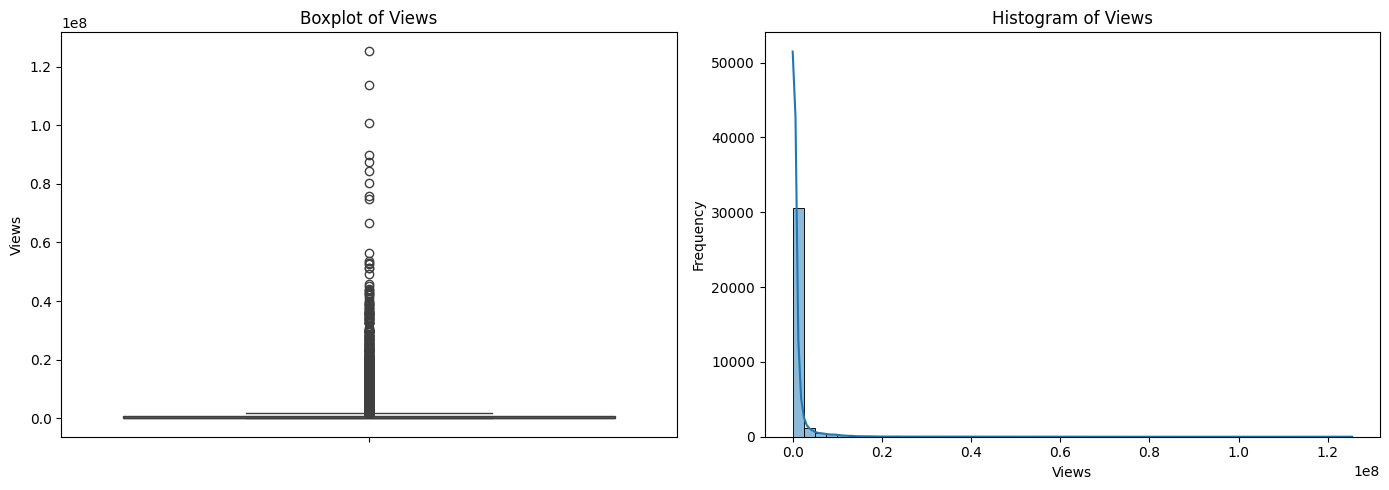

In [82]:
# Q: Draw a boxplot & Histogram for the 'views' column to check distribution and possible outliers


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=unique_youtube_df['views'])
plt.title("Boxplot of Views")
plt.ylabel("Views")

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(unique_youtube_df['views'], bins=50, kde=True)
plt.title("Histogram of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [83]:
# Detect outliers in the 'views' column using the IQR method

# Check skewness
skewness = unique_youtube_df['views'].skew()
print("Skewness:", round(skewness, 2))

# Calculate Q1, Q3, and IQR
Q1 = unique_youtube_df['views'].quantile(0.25)
Q3 = unique_youtube_df['views'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_IQR = unique_youtube_df.loc[
    (unique_youtube_df['views'] < lower_bound) |
    (unique_youtube_df['views'] > upper_bound)
].copy()

# Display outliers sorted by views
outliers_IQR.sort_values(by='views', ascending=False).reset_index(drop=True)

Skewness: 13.03


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,FlsCjmMhFmw,2017-12-12,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",125432237,2912710,1545017,807558,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
1,FlsCjmMhFmw,2017-12-11,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",113876217,2811216,1470387,787174,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
2,FlsCjmMhFmw,2017-12-10,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",100911567,2656672,1353650,682890,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
3,6ZfuNTqbHE8,2017-12-07,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",89930713,2606663,53011,347982,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,2017-11-29 00:00:00+00:00,13:26:24
4,6ZfuNTqbHE8,2017-12-06,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",87449453,2584674,52176,341571,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,2017-11-29 00:00:00+00:00,13:26:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3779,MiUFhVrG598,2018-03-29,Golak Bugni Bank Te Batua | Official Trailer |...,Rhythm Boyz,24,2018-03-24 06:30:07+00:00,"golak|""bugni""|""bank""|""te""|""batua""|""golak bugni...",1664547,23910,597,1402,https://i.ytimg.com/vi/MiUFhVrG598/default.jpg,False,False,False,Rhythm Boyz Entertainment & Hayre Omjee Studio...,2018-03-24 00:00:00+00:00,06:30:07
3780,7HVPdTTuDno,2018-03-30,"Steve Smith breaks down, says ball-tampering s...",Hindustan Times,25,2018-03-29 09:35:06+00:00,"hindustan times|""ht media""|""ht news""|""Hindusta...",1664258,16201,1140,3678,https://i.ytimg.com/vi/7HVPdTTuDno/default.jpg,False,False,False,Steve Smith started crying as he reflected on ...,2018-03-29 00:00:00+00:00,09:35:06
3781,3hGW_HKwh54,2018-04-02,Pagg Di Pooni (Full Video) | Hardeep Grewal | ...,VehliJantaRecords,10,2018-03-31 04:30:39+00:00,"hardeep grewal|""HARDEEP GREWAL""|""PAGG DI POONI...",1663852,17619,333,1174,https://i.ytimg.com/vi/3hGW_HKwh54/default.jpg,False,False,False,Vehli Janta Records & Manpreet Johal Presentin...,2018-03-31 00:00:00+00:00,04:30:39
3782,nLHC3pGgwj4,2018-04-24,ScoopWhoop: When A Desi Mom Visits You After M...,ScoopWhoop,24,2018-04-20 11:30:01+00:00,"ScoopWhoop|""India""|""funny""|""New""|""When A Desi ...",1663349,36905,3924,752,https://i.ytimg.com/vi/nLHC3pGgwj4/default.jpg,False,False,False,"To a mom, you'd still be her little baby wheth...",2018-04-20 00:00:00+00:00,11:30:01


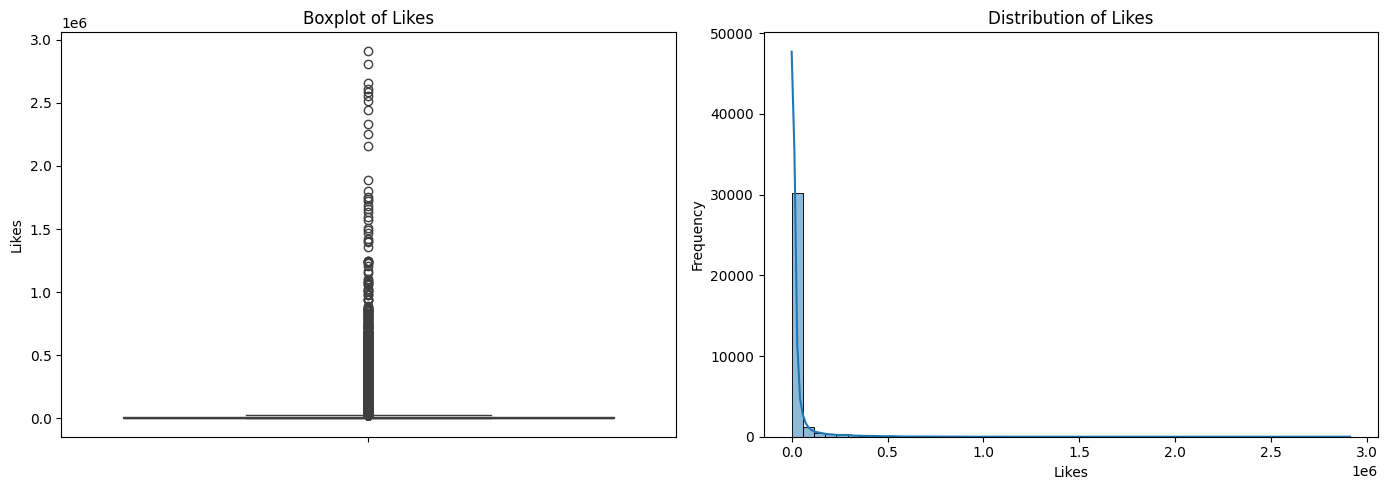

In [84]:
# Plot the distribution and potential outliers of 'likes'

plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=unique_youtube_df['likes'])
plt.title('Boxplot of Likes')
plt.ylabel('Likes')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(unique_youtube_df['likes'], bins=50, kde=True)
plt.title('Distribution of Likes')
plt.xlabel('Likes')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [89]:
# Detect outliers in the 'likes' column using the IQR method

# Check skewness
skewness = unique_youtube_df['likes'].skew()
print("Skewness:", round(skewness, 2))

# Calculate Q1, Q3, and IQR
Q1 = unique_youtube_df['likes'].quantile(0.25)
Q3 = unique_youtube_df['likes'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_IQR = unique_youtube_df.loc[
    (unique_youtube_df['likes'] < lower_bound) |
    (unique_youtube_df['likes'] > upper_bound)
].copy()

# Display outliers sorted by likes
outliers_IQR.sort_values(by='likes', ascending=False).reset_index(drop=True)

Skewness: 11.68


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,FlsCjmMhFmw,2017-12-12,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",125432237,2912710,1545017,807558,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
1,FlsCjmMhFmw,2017-12-11,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",113876217,2811216,1470387,787174,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
2,FlsCjmMhFmw,2017-12-10,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",100911567,2656672,1353650,682890,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
3,6ZfuNTqbHE8,2017-12-07,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",89930713,2606663,53011,347982,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,2017-11-29 00:00:00+00:00,13:26:24
4,6ZfuNTqbHE8,2017-12-06,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",87449453,2584674,52176,341571,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,2017-11-29 00:00:00+00:00,13:26:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5028,f-ODGYVExXs,2018-03-13,HYDERABADI AUTO LIFE || Hyderabad Diaries,Hyderabad Diaries,24,2018-03-09 09:51:38+00:00,"Hyderabad|""Diaries""|""hyderabad diaries""|""shahr...",305681,28895,1530,1347,https://i.ytimg.com/vi/f-ODGYVExXs/default.jpg,False,False,False,DOWNLOAD OUR APP:\n\nANDROID: https://play.goo...,2018-03-09 00:00:00+00:00,09:51:38
5029,YbQrFrpzcoA,2017-12-12,AAPKO KAL PROPOSE KARUNGA - TST - Bakchodi ki ...,TroubleSeekerTeam,23,2017-12-09 16:00:24+00:00,"aapko kal propose karunga|""latest video""|""bakc...",421950,28889,1590,1625,https://i.ytimg.com/vi/YbQrFrpzcoA/default.jpg,False,False,False,Subscribe Karo Aur Bell Icon Pe Click Karo - h...,2017-12-09 00:00:00+00:00,16:00:24
5030,D4uWz6rm0RQ,2018-04-14,Pawan Kalyan Full Speech | Rangasthalam Vijayo...,Mythri Movie Makers,24,2018-04-13 16:24:54+00:00,"Pawan Kalyan Full Speech|""Rangasthalam Vijayot...",1475449,28882,2097,2851,https://i.ytimg.com/vi/D4uWz6rm0RQ/default.jpg,False,False,False,Pawan Kalyan Full Speech at Rangasthalam Vijay...,2018-04-13 00:00:00+00:00,16:24:54
5031,CHZAj_kaHuY,2018-01-22,Gumrah - BOHEMIA (Official Audio),BOHEMIA,10,2018-01-19 04:20:23+00:00,"bohemia the punjabi rapper|""bohemia""|""dedicate...",410783,28878,359,5115,https://i.ytimg.com/vi/CHZAj_kaHuY/default.jpg,False,False,False,"Written composed and performed by BOHEMIA, #Gu...",2018-01-19 00:00:00+00:00,04:20:23


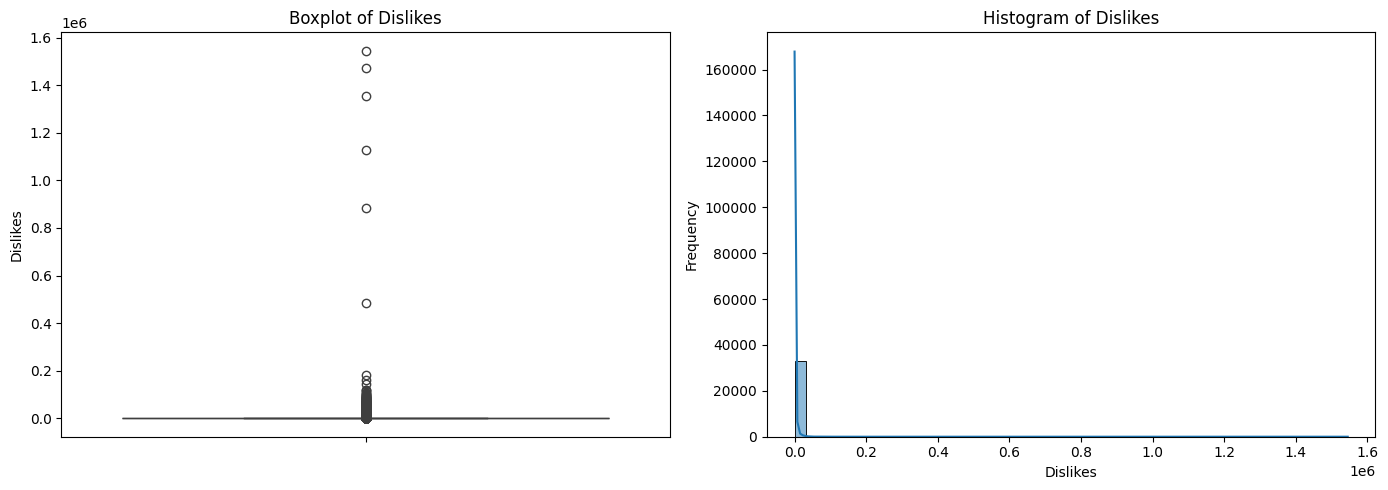

In [65]:
# Plot the distribution and potential outliers of 'dislikes'

plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=unique_youtube_df['dislikes'])
plt.title('Boxplot of Dislikes')
plt.ylabel('Dislikes')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(unique_youtube_df['dislikes'], bins=50, kde=True)
plt.title('Distribution of Dislikes')
plt.xlabel('Dislikes')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [87]:
# Detect outliers in the 'dislikes' column using the IQR method

# Check skewness
skewness = unique_youtube_df['dislikes'].skew()
print("Skewness:", round(skewness, 2))

# Calculate Q1, Q3, and IQR
Q1 = unique_youtube_df['dislikes'].quantile(0.25)
Q3 = unique_youtube_df['dislikes'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_IQR = unique_youtube_df.loc[
    (unique_youtube_df['dislikes'] < lower_bound) |
    (unique_youtube_df['dislikes'] > upper_bound)
].copy()

# Display outliers sorted by dislikes
outliers_IQR.sort_values(by='dislikes', ascending=False).reset_index(drop=True)

Skewness: 72.67


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,FlsCjmMhFmw,2017-12-12,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",125432237,2912710,1545017,807558,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
1,FlsCjmMhFmw,2017-12-11,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",113876217,2811216,1470387,787174,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
2,FlsCjmMhFmw,2017-12-10,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",100911567,2656672,1353650,682890,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
3,FlsCjmMhFmw,2017-12-09,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",75969469,2251815,1127805,827755,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
4,FlsCjmMhFmw,2017-12-08,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",52611730,1891811,884954,702784,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3953,RBWw1S0dX08,2018-04-19,A Day Before Appraisal || The Screen Patti,The Screen Patti,24,2018-04-16 13:12:57+00:00,"the screen patti|""tsp""|""the""|""screen""|""patti""|...",1062359,36691,2185,2507,https://i.ytimg.com/vi/RBWw1S0dX08/default.jpg,False,False,False,Appraisal Day.\nExpectation - The one time in ...,2018-04-16 00:00:00+00:00,13:12:57
3954,llK2CnVRprU,2018-02-15,Eruma Saani | Valentines Day Attrocities,Eruma Saani,23,2018-02-13 19:03:22+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1194114,60467,2185,1597,https://i.ytimg.com/vi/llK2CnVRprU/default.jpg,False,False,False,This is a video about how every 'single' boy a...,2018-02-13 00:00:00+00:00,19:03:22
3955,ZSd1Ll2nnCw,2018-05-29,Sudheer Propose To Rashmi | Funny Task | Dhee ...,ETV Dhee,24,2018-05-23 22:39:46+00:00,"etv shows|""eenadu television""|""padutha theeyag...",3825372,42048,2185,4805,https://i.ytimg.com/vi/ZSd1Ll2nnCw/default.jpg,False,False,False,దక్షణ భారతదేశంలోనే అతిపెద్ద డాన్స్ రియాలిటీ షో...,2018-05-23 00:00:00+00:00,22:39:46
3956,g6zBLhnBxks,2017-12-25,Velaikkaran review by Prashanth,tamilcinemareview,1,2017-12-22 06:31:47+00:00,"tamil cinema review|""tamil cinema review prash...",652130,11488,2184,1364,https://i.ytimg.com/vi/g6zBLhnBxks/default.jpg,False,False,False,https://yourstore.in/ - App to Find best Groce...,2017-12-22 00:00:00+00:00,06:31:47


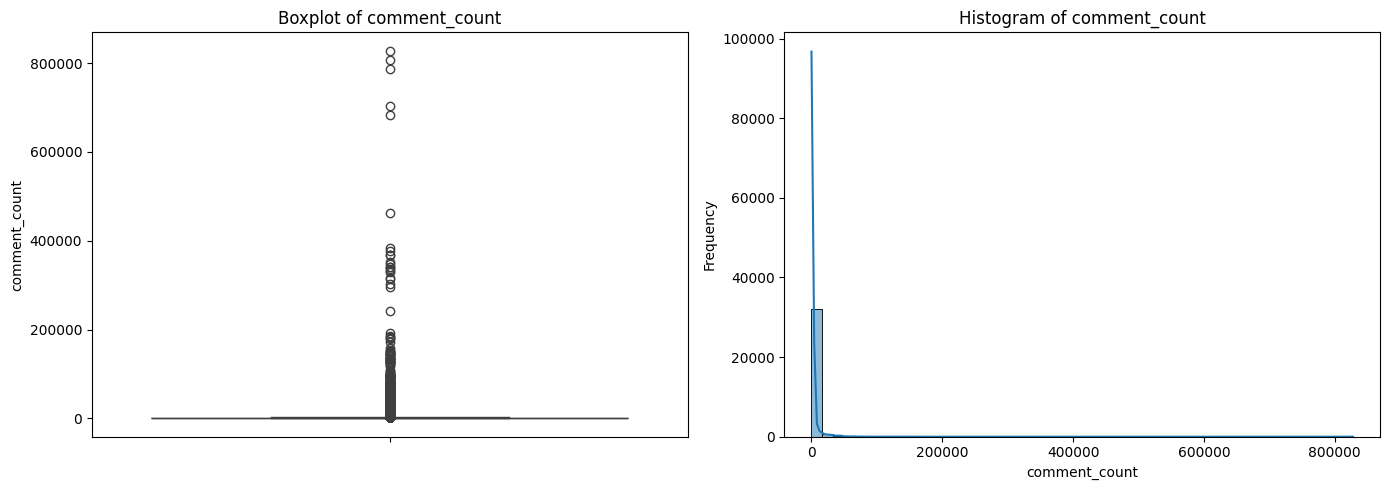

In [91]:
# Plot the distribution and potential outliers of 'comment_count'


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=unique_youtube_df['comment_count'])
plt.title("Boxplot of comment_count")
plt.ylabel("comment_count")

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(unique_youtube_df['comment_count'], bins=50, kde=True)
plt.title("Histogram of comment_count")
plt.xlabel("comment_count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [92]:
# Detect outliers in the 'comment_count' column using the IQR method

# Check skewness
skewness = unique_youtube_df['comment_count'].skew()
print("Skewness:", round(skewness, 2))

# Calculate Q1, Q3, and IQR
Q1 = unique_youtube_df['comment_count'].quantile(0.25)
Q3 = unique_youtube_df['comment_count'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_IQR = unique_youtube_df.loc[
    (unique_youtube_df['comment_count'] < lower_bound) |
    (unique_youtube_df['comment_count'] > upper_bound)
].copy()

# Display outliers sorted by comment_count
outliers_IQR.sort_values(by='comment_count', ascending=False).reset_index(drop=True)

Skewness: 29.16


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
0,FlsCjmMhFmw,2017-12-09,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",75969469,2251815,1127805,827755,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
1,FlsCjmMhFmw,2017-12-12,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",125432237,2912710,1545017,807558,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
2,FlsCjmMhFmw,2017-12-11,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",113876217,2811216,1470387,787174,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
3,FlsCjmMhFmw,2017-12-08,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",52611730,1891811,884954,702784,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
4,FlsCjmMhFmw,2017-12-10,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,24,2017-12-06 17:58:51+00:00,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",100911567,2656672,1353650,682890,https://i.ytimg.com/vi/FlsCjmMhFmw/default.jpg,False,False,False,"YouTube Rewind 2017. Celebrating the videos, p...",2017-12-06 00:00:00+00:00,17:58:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,WJ6F9NG2UWo,2018-03-24,Nanak Shah Fakir | Official Trailer - Releasin...,Viacom18 Motion Pictures,24,2018-03-22 12:49:16+00:00,"nanak shah fakir|""nanak shah fakir trailer""|""n...",1245334,25732,945,2819,https://i.ytimg.com/vi/WJ6F9NG2UWo/default.jpg,False,False,False,Here's presenting the official trailer of 'Nan...,2018-03-22 00:00:00+00:00,12:49:16
4273,cdVrQWiZOvI,2018-05-15,A DAY WITHOUT MOTHER | Aashqeen,Aashqeen,23,2018-05-13 06:04:31+00:00,"aashqeen|""funny""|""comedy""|""bb ki vines""|""lates...",578387,39664,1058,2818,https://i.ytimg.com/vi/cdVrQWiZOvI/default.jpg,False,False,False,Moms are born with some super natural powers o...,2018-05-13 00:00:00+00:00,06:04:31
4274,vsvImg6LEHA,2018-01-19,Shilpa Shinde's exclusive interview after winn...,Saas Bahu aur Saazish,24,2018-01-16 10:42:07+00:00,"Abp news|""news""|""breaking news""|""saas bahu aur...",884063,10002,2054,2815,https://i.ytimg.com/vi/vsvImg6LEHA/default.jpg,False,False,False,Shilpa Shinde's exclusive interview after winn...,2018-01-16 00:00:00+00:00,10:42:07
4275,79W4w1iNPAg,2018-02-16,Redmi Note 5 Pro Mere Thoughts Use Karne Ke Baad,GeekyRanjit In Hindi,28,2018-02-14 07:29:41+00:00,"redmi note 5 pro|""redmi note 5 pro hindi""|""red...",801116,20385,1013,2815,https://i.ytimg.com/vi/79W4w1iNPAg/default.jpg,False,False,False,Xiaomi Redmi Note 5 Pro Smartphone Ke thoughts...,2018-02-14 00:00:00+00:00,07:29:41


In [93]:
# Find videos with the highest number of views
# and sort them in descending order

# Keep only valid YouTube video IDs
unique_youtube_df_valid = unique_youtube_df[
    unique_youtube_df['video_id'].str.match(r'^[A-Za-z0-9_-]{11}$', na=False)
]

# Find maximum views for each video
dt = unique_youtube_df_valid.groupby('video_id')['views'].max().reset_index()

# Sort by views in descending order
dt = dt.sort_values(by='views', ascending=False).reset_index(drop=True)

dt

,video_id,views
0,FlsCjmMhFmw,125432237
1,6ZfuNTqbHE8,89930713
2,u9Mv98Gr5pY,53822757
3,QwievZ1Tx-8,45064699
4,rRr1qiJRsXk,44171797
...,...,...
16300,4fKgKl8W3ws,5437
16301,p3Wn9FuI2zo,5098
16302,18OSLOq-bFA,4359
16303,iW5ZRboFCMU,4287


In [94]:
# Which video trended for the most number of days?

youtube_trending_df = unique_youtube_df_valid.groupby('video_id').agg(
    min_trending=('trending_date', 'min'),
    max_trending=('trending_date', 'max')
).reset_index()

youtube_trending_df['trending_days'] = (
    youtube_trending_df['max_trending'] - youtube_trending_df['min_trending']
).dt.days

youtube_trending_df = youtube_trending_df.sort_values(
    by='trending_days', ascending=False
).reset_index(drop=True)

youtube_trending_df.loc[
    youtube_trending_df['trending_days'] == youtube_trending_df['trending_days'].max(),
    'video_id'
]

,video_id
0,rRr1qiJRsXk
1,FPm7xM849-E


In [99]:
# Which videos are trending on the same day of upload?

x = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['publish_date'] == unique_youtube_df_valid['trending_date']
]

x_unique_row = x.drop_duplicates(
    subset=['video_id', 'trending_date', 'publish_date']
)

x_unique_row[['video_id', 'trending_date', 'publish_date']]

,video_id,trending_date,publish_date
430,bvmlbu5Vipg,2017-11-16,2017-11-16
2325,_r0mH98oPlg,2017-11-26,2017-11-26
2855,j_Vlg4K05s8,2017-11-29,2017-11-29
3633,Khg8JCK6PMI,2017-12-03,2017-12-03
5285,wS7okEDsAWI,2017-12-12,2017-12-12
...,...,...,...
32574,pq-eP_RCclI,2018-06-10,2018-06-10
32644,fUoc7FMuwdY,2018-06-11,2018-06-11
32651,8_ei7sQJ4FY,2018-06-11,2018-06-11
32701,z7ddTuNukvQ,2018-06-11,2018-06-11


In [100]:
# Find top 4 channels with the most number of same-day trending videos

x = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['publish_date'] == unique_youtube_df_valid['trending_date']
]

x.groupby('channel_title')['video_id'].count().sort_values(
    ascending=False
).head(4)

,video_id
channel_title,
Adda247 :Official Channel of BankersAdda & SSCAdda,48
WiFiStudy,28
Mahendra Guru : Online Videos For Govt. Exams,16
Study IQ education,12


In [102]:
# What factors contribute to a video going viral on YouTube?

# Factor: 'trending_date'

# Convert dates to datetime
unique_youtube_df_valid['trending_date'] = pd.to_datetime(
    unique_youtube_df_valid['trending_date']
)

unique_youtube_df_valid['publish_date'] = pd.to_datetime(
    unique_youtube_df_valid['publish_date']
)

# Total number of days trending
youtube_trending_df = unique_youtube_df_valid.groupby('video_id').agg(
    min_trending=('trending_date', 'min'),
    max_trending=('trending_date', 'max')
).reset_index()

youtube_trending_df['trending_days'] = (
    youtube_trending_df['max_trending'] -
    youtube_trending_df['min_trending']
).dt.days

youtube_trending_df.sort_values(
    by='trending_days', ascending=False
).reset_index(drop=True)

# Trending on the same day as publication
x = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['publish_date'] ==
    unique_youtube_df_valid['trending_date']
]

x

/tmp/ipykernel_665/2391025247.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_youtube_df_valid['trending_date'] = pd.to_datetime(
/tmp/ipykernel_665/2391025247.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_youtube_df_valid['publish_date'] = pd.to_datetime(


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_timeline
430,bvmlbu5Vipg,2017-11-16,गुरुवार स्पेशल भजन : साईं बाबा रहमत की नज़र कर ...,Sonotek Bhakti,10,2017-11-16 00:00:02+00:00,"bhajan bhakti|""ras""|""kirtan""|""sonotek bhakti""|...",66756,442,58,56,https://i.ytimg.com/vi/bvmlbu5Vipg/default.jpg,False,False,False,भक्ति पूर्ण गानों के लिए क्लिक करें | http://g...,2017-11-16,00:00:02
2325,_r0mH98oPlg,2017-11-26,RAMAYANAM PART- 7 | Bahubali Ramayanam | Unkno...,Vikram Aditya,24,2017-11-26 03:04:54+00:00,"Ramayanam in Telugu By Vikram Aditya|""Bahubali...",52202,2165,204,859,https://i.ytimg.com/vi/_r0mH98oPlg/default.jpg,False,False,False,CARWASH KARO: 1800-1234-226\n\nRAJAMOULI INTER...,2017-11-26,03:04:54
2855,j_Vlg4K05s8,2017-11-29,Dil De Kareeb | Garry Sandhu ( Full Video ) | ...,Fresh Media Records,10,2017-11-29 02:36:54+00:00,"punjabi new songs 2017 dil de kareeb|""koi sala...",283742,28088,299,3806,https://i.ytimg.com/vi/j_Vlg4K05s8/default.jpg,False,False,False,We are Presenting New Punjabi Song Dil De Kare...,2017-11-29,02:36:54
3633,Khg8JCK6PMI,2017-12-03,RAMAYANAM PART - 10 | CLIMAX | Unknown Facts A...,Vikram Aditya,24,2017-12-03 03:00:52+00:00,"RAMAYANAM PART - 10|""Unknown Facts About Ramay...",60051,3107,73,1777,https://i.ytimg.com/vi/Khg8JCK6PMI/default.jpg,False,False,False,"RAMAYANAM in Telugu By Vikram Aditya , Part 10...",2017-12-03,03:00:52
5285,wS7okEDsAWI,2017-12-12,"हनुमान चालीसा, Hanuman Chalisa Hari Om Sharan ...",T-Series Bhakti Sagar,10,2017-12-12 01:30:01+00:00,"Hanuman Chalisa|""hanuman Chalisa Hari Om Shara...",36535,370,37,49,https://i.ytimg.com/vi/wS7okEDsAWI/default.jpg,False,False,False,Hanuman Bhajan: Hanuman Chalisa By Hari Om Sha...,2017-12-12,01:30:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32574,pq-eP_RCclI,2018-06-10,ఏసీల్లో కూర్చొని ఎవరైనా మాట్లాడుతారు..,Sakshi TV,25,2018-06-10 07:10:32+00:00,"hero vishal|""actor vishal""|""abhimanyudu movie""...",95939,0,0,0,https://i.ytimg.com/vi/pq-eP_RCclI/default.jpg,True,True,False,ఏసీల్లో కూర్చొని ఎవరైనా మాట్లాడుతారు.. --Watch...,2018-06-10,07:10:32
32644,fUoc7FMuwdY,2018-06-11,CET Common Eligibility test & Its Effect on st...,CGL APTITUDE PATHSHALA,27,2018-06-11 02:04:22+00:00,"SSC CGL|""SSC CHSL""|""SSC CGL 2018""|""BANK PO""|""I...",21663,944,82,454,https://i.ytimg.com/vi/fUoc7FMuwdY/default.jpg,False,False,False,NaN,2018-06-11,02:04:22
32651,8_ei7sQJ4FY,2018-06-11,CURRENT AFFAIRS | THE HINDU |10-11th June 2018...,Adda247 :Official Channel of BankersAdda & SSC...,27,2018-06-11 03:25:05+00:00,"adda247|""bankersadda""|""ssc""|""sbi""|""SSC""|""SBI B...",18658,2197,36,71,https://i.ytimg.com/vi/8_ei7sQJ4FY/default.jpg,False,False,False,Adda247_Mega_Supreme is Active NowGo For Your ...,2018-06-11,03:25:05
32701,z7ddTuNukvQ,2018-06-11,Khubsurat Bewafa | KIRAN GAJERA | खूबसूरत बेवफ...,Studio Saraswati Official,10,2018-06-11 02:26:14+00:00,"kirtidan gadhavi|""tahukar""|""jay mogal""|""maa mo...",78118,2143,161,166,https://i.ytimg.com/vi/z7ddTuNukvQ/default.jpg,False,False,False,Producer : MANOJ N JOBANPUTRA.Lyrics : RAJAN ...,2018-06-11,02:26:14


In [103]:
# What factors contribute to a video going viral on YouTube?

## Factor: Engagement ratios

# 1. View/comment ratio

def vc(df):
    df['view_comment_ratio'] = round(
        df['views'] / df['comment_count'], 2
    )
    return df.sort_values('view_comment_ratio', ascending=False)

unique_youtube_df_valid.groupby('video_id').apply(vc)


# 2. View/like ratio

def vl(df):
    df['view_like_ratio'] = round(
        df['views'] / df['likes'].astype(float), 2
    )
    return df.sort_values('view_like_ratio', ascending=False)

unique_youtube_df_valid.groupby('video_id').apply(vl)


# 3. Like/dislike ratio

def ld(df):
    df['like_dislike_ratio'] = round(
        df['likes'] / df['dislikes'], 2
    )
    return df.sort_values('like_dislike_ratio', ascending=False)

unique_youtube_df_valid.groupby('video_id').apply(ld)

/tmp/ipykernel_665/2068191394.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_youtube_df_valid.groupby('video_id').apply(vc)
/tmp/ipykernel_665/2068191394.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_youtube_df_valid.groupby('video_id').apply(vl)
/tmp/ipykernel_665/2068191394.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depre

video_id trending_date  \
video_id                                       
-0N9r10xb_0 1039   -0N9r10xb_0    2017-11-19   
            1224   -0N9r10xb_0    2017-11-20   
-0WuM6ctLHg 16050  -0WuM6ctLHg    2018-02-11   
            16254  -0WuM6ctLHg    2018-02-12   
            16459  -0WuM6ctLHg    2018-02-13   
...                        ...           ...   
zyvYkpoLeSU 14381  zyvYkpoLeSU    2018-01-31   
            14247  zyvYkpoLeSU    2018-01-30   
zz6Nqy4SM3E 25217  zz6Nqy4SM3E    2018-04-17   
            25390  zz6Nqy4SM3E    2018-04-18   
zzcAq02ncAE 27428  zzcAq02ncAE    2018-05-02   

                                                               title  \
video_id                                                               
-0N9r10xb_0 1039   19 नवंबर शनि अमावस्या के अगले दिन बड़ा रविवार ब...   
            1224   19 नवंबर शनि अमावस्या के अगले दिन बड़ा रविवार ब...   
-0WuM6ctLHg 16050  மிரளவைக்கும் 5 நம்பமுடியாத கண்டுபிடிப்புகள் | ...   
            16254  மிரளவைக்கும் 5 நம்பமுடியாத கண்டுபிடிப்புகள் | ...   
            16459  மிரளவைக்கும் 5 நம்பமுடியாத கண்டுபிடிப்புகள் | ...   
...                                                              ...   
zyvYkpoLeSU 14381  Bigg Boss 5 Kannada Winner | Kannada Big Boss ...   
            14247  Bigg Boss 5 Kannada Winner | Kannada Big Boss ...   
zz6Nqy4SM3E 25217  Funny College Scenes ft. Pichi Yakuu | Waranga...   
            25390  Funny College Scenes ft. Pichi Yakuu | Waranga...   
zzcAq02ncAE 27428  ANT-MAN AND THE WASP Trailer # 2 TEASER (NEW 2...   

                      channel_title  category_id              publish_time  \
video_id                                                                     
-0N9r10xb_0 1039     Magical Nuskhe           26 2017-11-18 14:20:54+00:00   
            1224     Magical Nuskhe           26 2017-11-18 14:20:54+00:00   
-0WuM6ctLHg 16050    Kollywood Talk           22 2018-02-10 08:07:15+00:00   
            16254    Kollywood Talk           22 2018-02-10 08:07:15+00:00   
            16459    Kollywood Talk           22 2018-02-10 08:07:15+00:00   
...                             ...          ...                       ...   
zyvYkpoLeSU 14381         Namma KFI           24 2018-01-28 17:59:20+00:00   
            14247         Namma KFI           24 2018-01-28 17:59:20+00:00   
zz6Nqy4SM3E 25217  Warangal Diaries           23 2018-04-16 08:03:55+00:00   
            25390  Warangal Diaries           23 2018-04-16 08:03:55+00:00   
zzcAq02ncAE 27428         ONE Media            1 2018-04-30 22:25:33+00:00   

                                                                tags    views  \
video_id                                                                        
-0N9r10xb_0 1039   19 नवंबर शनि अमावस्या के अगले दिन बड़ा रविवार ब...    71064   
            1224   19 नवंबर शनि अमावस्या के अगले दिन बड़ा रविवार ब...   133438   
-0WuM6ctLHg 16050  amazing invention|"amazing bike in the world"|...   179951   
            16254  amazing invention|"amazing bike in the world"|...   310078   
            16459  amazing invention|"amazing bike in the world"|...   333432   
...                                                              ...      ...   
zyvYkpoLeSU 14381  chandan shetty big boss songs|"bigg boss kanna...    58563   
            14247  chandan shetty big boss songs|"bigg boss kanna...    49440   
zz6Nqy4SM3E 25217  warangal diaries|"latest"|"funny"|"comedy"|"Ba...   108494   
            25390  warangal diaries|"latest"|"funny"|"comedy"|"Ba...   153387   
zzcAq02ncAE 27428  Cinema|"Trailer"|"Official"|"Movie"|"Film"|"An...  1089236   

                   likes  dislikes  comment_count  \
video_id                                            
-0N9r10xb_0 1039    1061       122             16   
            1224    1381       208             39   
-0WuM6ctLHg 16050   3076       109             82   
            16254   3878       147             94   
            16459   4086       161             96   
...                 

In [104]:
# What factors contribute to a video going viral on YouTube?

## Factor: Category Breakdown

round(
    unique_youtube_df_valid.groupby('category_id')['views'].mean(),
    2
).sort_values(ascending=False)

,views
category_id,
20,3781228.02
30,3191953.00
10,2492320.95
15,2367727.50
1,2251642.96
17,1805161.32
24,897170.78
26,846336.18
28,845791.52


In [105]:
# What factors contribute to a video going viral on YouTube?

## Factor: Channel Breakdown

round(
    unique_youtube_df_valid.groupby('channel_title')['views'].mean(),
    2
).sort_values(ascending=False)

,views
channel_title,
YouTube Spotlight,82264347.17
TaylorSwiftVEVO,28542566.00
FoxStarHindi,22339854.91
Sony Pictures Entertainment,21759971.59
Marvel Entertainment,20335860.98
...,...
Reporter Roy,11816.00
Viral in India,11391.00
Wide Angle Pictures,11337.00


In [109]:
# What factors contribute to a video going viral on YouTube?

# Factor: Publishing hour

unique_youtube_df_valid['publish_hour'] = unique_youtube_df_valid[
    'publish_timeline'
].apply(lambda x: x.hour)

round(
    unique_youtube_df_valid.groupby('publish_hour')['views'].mean(), 2
).sort_values(ascending=False)

,views
publish_hour,
13,1482306.65
21,1379097.06
1,1296025.94
18,1216895.13
4,1199307.53
7,1198491.95
22,1160352.18
5,1108084.78
20,1099820.77


In [111]:
# What factors contribute to a video going viral on YouTube?

## Factor: Correlation between views and
## 'comments_disabled', 'ratings_disabled', 'video_error_or_removed'

corr_with_views = unique_youtube_df_valid[
    ['views', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']
].corr()['views'].drop('views')

corr_with_views

,views
comments_disabled,-0.033061
ratings_disabled,-0.033261
video_error_or_removed,0.006760


In [113]:
# Do certain categories have a higher chance of going viral?

# Take the top 10% of views as the viral threshold
viral_threshold = unique_youtube_df_valid['views'].quantile(0.90)

viral_vid_df = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['views'] >= viral_threshold
]

# Calculate average views of viral videos by category
category_viral = round(
    viral_vid_df.groupby('category_id')['views'].mean(), 2
).sort_values(ascending=False)

category_viral

,views
category_id,
28,8793921.68
24,7531441.19
1,7233367.44
10,7032912.39
20,5724289.58
17,5594634.96
30,5070116.50
27,3747371.50
23,3727802.95


In [114]:
# Q: Do certain channels have a higher chance of going viral?

# Take the top 10% of views as the viral threshold
viral_threshold = unique_youtube_df_valid['views'].quantile(0.90)

viral_vid_df = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['views'] >= viral_threshold
]

# Calculate average views of viral videos by channel
channel_viral = round(
    viral_vid_df.groupby('channel_title')['views'].mean(), 2
).sort_values(ascending=False)

channel_viral

,views
channel_title,
YouTube Spotlight,82264347.17
TaylorSwiftVEVO,30843584.08
Marvel Entertainment,29815524.11
Google,26783007.33
FoxStarHindi,25029544.59
...,...
Bhavani HD Movies,1907673.00
Blockbuster Movies,1905684.00
Gaurav Chaudhary,1895756.50


In [115]:
# Do certain categories have a higher chance of going viral?

# Take the top 10% of views as the viral threshold
viral_threshold = unique_youtube_df_valid['views'].quantile(0.90)

viral_vid_df = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['views'] >= viral_threshold
]

# Calculate average views of viral videos by publishing hour
publish_hour_viral = round(
    viral_vid_df.groupby('publish_hour')['views'].mean(), 2
).sort_values(ascending=False)

publish_hour_viral

,views
publish_hour,
1,13019557.64
7,9999770.19
9,9107510.18
5,8144944.84
13,7873485.37
3,7858157.10
23,7266468.67
22,7257473.33
17,6994911.83


In [117]:
# Do certain title lengths have a higher chance of going viral?

# Calculate title length
unique_youtube_df_valid['title_length_chars'] = (
    unique_youtube_df_valid['title'].str.len()
)

# Group title lengths
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['<20', '20-40', '40-60', '60-80', '80-100', '>100']

unique_youtube_df_valid['title_length_group'] = pd.cut(
    unique_youtube_df_valid['title_length_chars'],
    bins=bins,
    labels=labels
).astype('object')

# Take the top 10% of views as the viral threshold
viral_threshold = unique_youtube_df_valid['views'].quantile(0.90)

viral_vid_df = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['views'] >= viral_threshold
]

# Average views of viral videos by title length
title_len_viral = round(
    viral_vid_df.groupby('title_length_group')['views'].mean(), 2
).sort_values(ascending=False)

title_len_viral

,views
title_length_group,
40-60,8407561.69
20-40,7136424.66
80-100,5885257.71
60-80,5293133.76
<20,4313718.64


In [119]:
# Do likes and dislikes impact the number of views?

cm = unique_youtube_df_valid[['views', 'likes', 'dislikes']].corr()

like_dislike_corr_with_views = cm.loc[
    ['likes', 'dislikes'], 'views'
]

like_dislike_corr_with_views

,views
likes,0.852733
dislikes,0.553807


In [120]:
# Which video category gets the highest engagement?

unique_youtube_df_valid['engagement'] = (
    unique_youtube_df_valid['likes'] +
    unique_youtube_df_valid['dislikes'] +
    unique_youtube_df_valid['comment_count']
)

unique_youtube_df_valid['engagement_rate'] = (
    unique_youtube_df_valid['engagement'] /
    unique_youtube_df_valid['views']
)

category_engagement = (
    unique_youtube_df_valid
    .groupby('category_id')
    .agg(
        avg_engagement=('engagement', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        total_videos=('video_id', 'count')
    )
    .sort_values('avg_engagement_rate', ascending=False)
    .reset_index()
)

category_engagement

,category_id,avg_engagement,avg_engagement_rate,total_videos
0,28,51524.380117,0.107493,513
1,15,204756.500000,0.086575,2
2,23,55267.996256,0.061516,2938
3,27,6832.207465,0.061398,1152
4,20,109648.769231,0.042857,52
5,29,2301.980583,0.035963,103
6,10,71657.073171,0.028979,3239
7,2,8625.710145,0.026404,69
8,1,45503.681850,0.022658,1449
9,22,10083.868769,0.019719,2347


In [123]:
# How does the publishing time affect a video's success?

# Publish hour
unique_youtube_df_valid['publish_hour'] = (
    unique_youtube_df_valid['publish_timeline'].apply(lambda x: x.hour)
)

view_each_publish_hr = (
    unique_youtube_df_valid.groupby('publish_hour')['views']
    .mean()
    .sort_values(ascending=False)
)

engagement_each_publish_hr = (
    unique_youtube_df_valid.groupby('publish_hour')['engagement']
    .mean()
    .sort_values(ascending=False)
)


# Publish day
unique_youtube_df_valid['publish_day'] = (
    unique_youtube_df_valid['publish_date'].dt.day_name()
)

view_each_publish_day = (
    unique_youtube_df_valid.groupby('publish_day')['views']
    .mean()
    .sort_values(ascending=False)
)

engagement_each_publish_day = (
    unique_youtube_df_valid.groupby('publish_day')['engagement']
    .mean()
    .sort_values(ascending=False)
)


# Viral videos
viral_threshold = unique_youtube_df_valid['views'].quantile(0.90)

viral_vid_df = unique_youtube_df_valid.loc[
    unique_youtube_df_valid['views'] >= viral_threshold
]

publish_hour_viral = round(
    viral_vid_df.groupby('publish_hour')['views'].mean(), 2
).sort_values(ascending=False)

print(publish_hour_viral)

publish_day_viral = round(
    viral_vid_df.groupby('publish_day')['views'].mean(), 2
).sort_values(ascending=False)

print(publish_day_viral)

publish_hour
1     13019557.64
7      9999770.19
9      9107510.18
5      8144944.84
13     7873485.37
3      7858157.10
23     7266468.67
22     7257473.33
17     6994911.83
16     6898336.49
6      6837569.75
21     6425936.67
12     6199459.03
2      5737403.87
14     5556018.70
15     5354766.18
0      5273137.38
8      5108552.57
10     5097472.77
11     4877032.27
18     4627613.30
4      4577826.18
20     4141829.29
19     3686412.33
Name: views, dtype: float64
publish_day
Wednesday    7977728.11
Tuesday      7773762.87
Thursday     6476763.14
Monday       6399475.90
Friday       5586606.76
Sunday       5235240.83
Saturday     4763045.87
Name: views, dtype: float64


In [124]:
# What is the ideal title length for maximizing views and engagement?

# Calculate title length
unique_youtube_df_valid['title_length_chars'] = (
    unique_youtube_df_valid['title'].str.len()
)

# Correlation between title length and views/engagement
corr_mtrx = unique_youtube_df_valid[
    ['title_length_chars', 'views', 'likes', 'comment_count']
].corr()

corr_mtrx_title_len = corr_mtrx.loc[
    ['views', 'likes', 'comment_count'], 'title_length_chars'
]

corr_mtrx_title_len


# Check minimum and maximum title length
unique_youtube_df_valid['title_length_chars'].min()
unique_youtube_df_valid['title_length_chars'].max()


# Group title lengths
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['<20', '20-40', '40-60', '60-80', '80-100', '>100']

unique_youtube_df_valid['title_length_group'] = pd.cut(
    unique_youtube_df_valid['title_length_chars'],
    bins=bins,
    labels=labels
).astype(object)


# Compare views and engagement by title length
title_stats = round(
    unique_youtube_df_valid
    .groupby('title_length_group')
    .agg(
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comment_count', 'mean'),
        count=('title', 'count')
    ),
    2
).sort_values(by='avg_views', ascending=False)

title_stats

,avg_views,avg_likes,avg_comments,count
title_length_group,,,,
20-40,1629193.15,69334.76,6480.74,3632
<20,1604674.40,104980.79,10481.04,289
40-60,1112105.29,34452.31,3911.85,6753
80-100,926071.46,15102.52,1194.52,13591
60-80,697856.90,13342.37,1574.13,8374
